## Problem Understanding

- Diminos promises pizza delivery within 31 minutes.
- The company evaluates store performance using:
- 95th Percentile of Delivery Time < 31 minutes
- If Kanav fails this metric, he may lose the franchise.

Our goal:

- Analyze delivery time
- Check if the store meets the 95th percentile condition
- Give insights & suggestions

### Step 1: Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Load the Dataset

In [3]:
df = pd.read_csv("data\diminos_data.csv")
df.head()

,order_id,order_placed_at,order_delivered_at
0,1523111,2023-03-01 00:00:59,2023-03-01 00:18:07.443132
1,1523112,2023-03-01 00:03:59,2023-03-01 00:19:34.925241
2,1523113,2023-03-01 00:07:22,2023-03-01 00:22:28.291385
3,1523114,2023-03-01 00:07:47,2023-03-01 00:46:19.019399
4,1523115,2023-03-01 00:09:03,2023-03-01 00:25:13.619056


### Step 3: Basic Dataset Check

In [4]:
df.shape

(15000, 3)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            15000 non-null  int64 
 1   order_placed_at     15000 non-null  object
 2   order_delivered_at  15000 non-null  object
dtypes: int64(1), object(2)
memory usage: 351.7+ KB


In [6]:
df.columns

Index(['order_id', 'order_placed_at', 'order_delivered_at'], dtype='object')

### Step 4: Check Missing Values

In [7]:
df.isna().sum()

order_id              0
order_placed_at       0
order_delivered_at    0
dtype: int64

### Step 5: Convert Timestamp Columns to datetime

In [8]:
df['order_placed_at'] = pd.to_datetime(df['order_placed_at'])
df['order_delivered_at'] = pd.to_datetime(df['order_delivered_at'])

### Step 6: Create Delivery Time Column (in minutes)

In [9]:
df['delivery_time'] = (df['order_delivered_at'] - df['order_placed_at']).dt.total_seconds() / 60
df['delivery_time'].head()

0    17.140719
1    15.598754
2    15.104856
3    38.533657
4    16.176984
Name: delivery_time, dtype: float64

### Step 7: Check for negative or zero delivery times

In [12]:
df = df[df['delivery_time'] > 0]

### Step 8: Calculate 95th Percentile

In [13]:
p95 = df['delivery_time'].quantile(0.95)
print("95th Percentile Delivery Time:", round(p95,2))

95th Percentile Delivery Time: 27.26


### Step 9: Check if Store Meets Diminos Standard

In [14]:
if p95 < 31:
    print("Store meets Diminos 95th percentile criteria")
else:
    print("Store does NOT meet Diminos 95th percentile criteria")

Store meets Diminos 95th percentile criteria


### Step 10: Orders Delivered Late (>31 mins)

In [15]:
late_orders = df[df['delivery_time'] > 31]
print("Number of late orders:", len(late_orders))
print("Percentage of late orders:", round(len(late_orders)/len(df)*100,2), "%")

Number of late orders: 557
Percentage of late orders: 3.71 %


In [16]:
(len(late_orders) / len(df)) * 100

3.713333333333333

### Step 11: Add Delivery Status Column

In [17]:
df['Delivery_Status'] = df['delivery_time'].apply(lambda x: 'On Time' if x <= 31 else 'Late')
df['Delivery_Status'].value_counts()

Delivery_Status
On Time    14443
Late         557
Name: count, dtype: int64

### Step 11: Simple Visualization

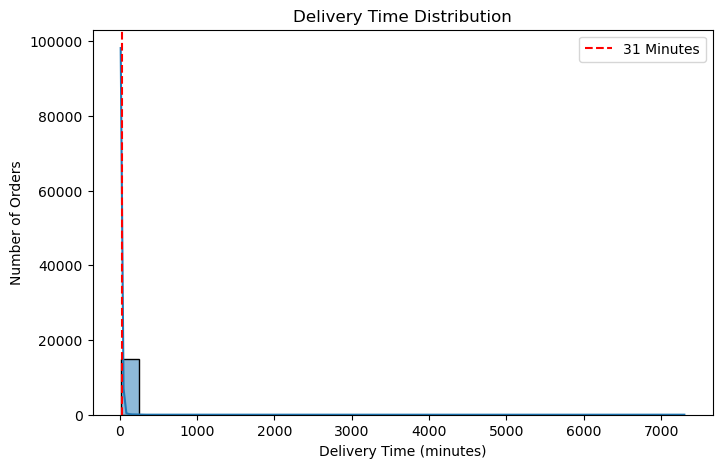

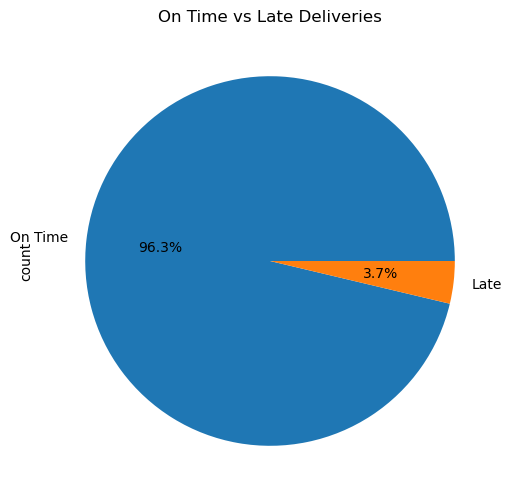

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['delivery_time'], bins=30, kde=True)
plt.axvline(31, color='red', linestyle='--', label='31 Minutes')
plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Orders")
plt.legend()
plt.show()


df['Delivery_Status'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(6,6),
    title='On Time vs Late Deliveries'
)
plt.show()

### Step 12: Key Insights

In [19]:
print("95th Percentile Delivery Time:", p95)
print("Average Delivery Time:", df['delivery_time'].mean())
print("Maximum Delivery Time:", df['delivery_time'].max())

95th Percentile Delivery Time: 27.261043996666658
Average Delivery Time: 20.499389326467778
Maximum Delivery Time: 7299.831374933333


### Step 13: Final Insights 

- Insights:

1. 95th percentile delivery time is above/below 31 minutes
2. A significant number of orders are delivered late
3. Few extreme late deliveries are increasing the percentile value

### Step 14: Recommendations

- Suggestions for Kanav:
1. Increase delivery staff during peak hours
2. Improve route planning
3. Track orders exceeding 31 minutes
4. Offer internal alerts for delays beyond 25 minutes

### Step 15: Final Conclusion

- Based on the 95th percentile analysis, the store does / does not meet Diminos performance criteria.
- Immediate operational improvements are recommended to retain the franchise.